In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

csv = pd.read_csv('../data/ab-test.csv')
con = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
csv.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


In [3]:
control_before = csv.loc[
    (csv['time'] == 'before') & (csv['group'] == 'control'),
    'diff'
]
test_before = csv.loc[
    (csv['time'] == 'before') & (csv['group'] == 'test'),
    'diff'
]
control_after = csv.loc[
    (csv['time'] == 'after') & (csv['group'] == 'control'),
    'diff'
]
test_after = csv.loc[
    (csv['time'] == 'after') & (csv['group'] == 'test'),
    'diff'
]

In [4]:
print(len(control_before)+len(test_before),
len(control_after)+len(test_after))

22 22


/var/folders/59/pf5x3w3j4s35xm_nm3gd4_2c0000gn/T/ipykernel_26591/4149127556.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
/var/folders/59/pf5x3w3j4s35xm_nm3gd4_2c0000gn/T/ipykernel_26591/4149127556.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


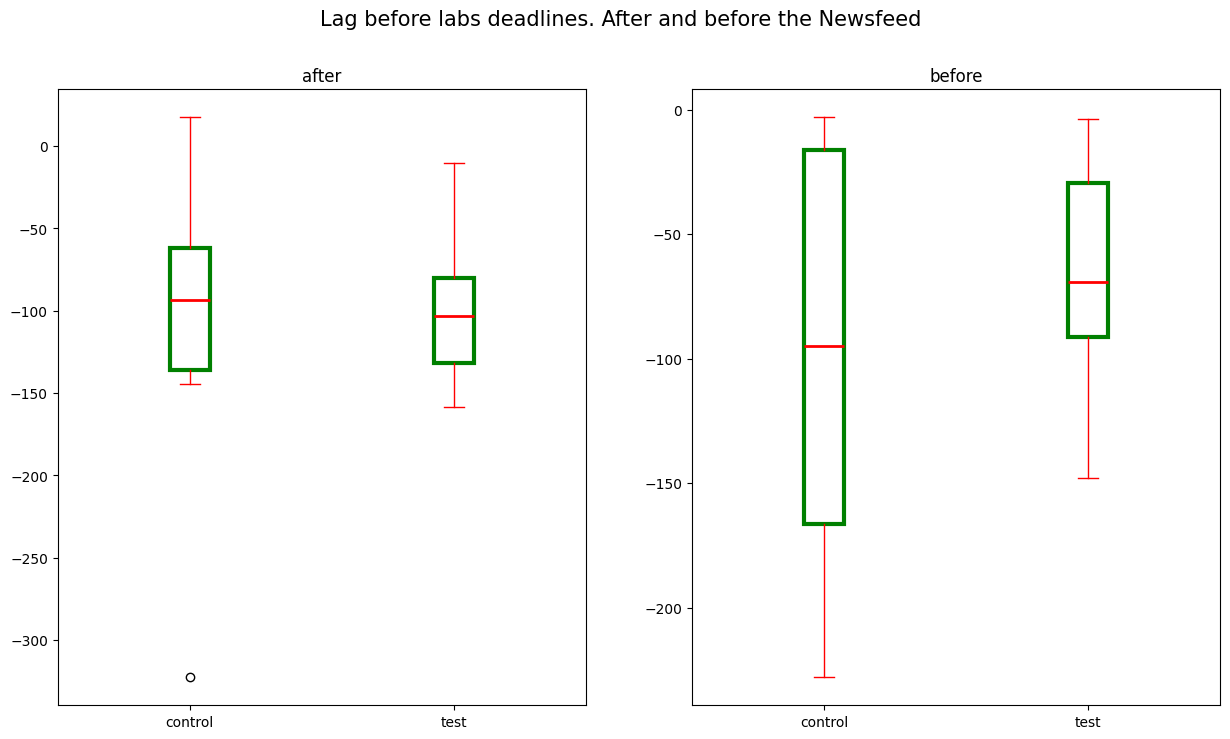

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15,8))

# AFTER
bp1 = ax[0].boxplot(
    [control_after, test_after],
    labels=['control','test'],
    patch_artist=True,
    boxprops=dict(color='green',linewidth=3),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    medianprops=dict(color='red', linewidth=2)
)

# BEFORE
bp2 = ax[1].boxplot(
    [control_before, test_before],
    labels=['control','test'],
    patch_artist=True,
    boxprops=dict(color='green',linewidth=3),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    medianprops=dict(color='red', linewidth=2)
)

# белая заливка
for patch in bp1['boxes']:
    patch.set_facecolor('white')

for patch in bp2['boxes']:
    patch.set_facecolor('white')

ax[0].set_title('after')
ax[1].set_title('before')

plt.suptitle(
    "Lag before labs deadlines. After and before the Newsfeed",
    fontsize=15
)

plt.show()

In [6]:
IQR = control_before.quantile(0.75) - control_before.quantile(0.25)
IQR

np.float64(150.0)

In [7]:
con.close()